In [13]:
import numpy as np
from io import StringIO
import glob

# proliferating e-anyons, m-anyons subthreshold

def load_error_rate(filename):
    """Read one output_*.txt file and return its 'Error Rate:' block as a 16x8 array."""
    with open(filename) as f:
        text = f.read()
    # grab everything between the "Error Rate:" header and the next blank line
    block = text.split("Error Rate:")[1].split("\n\n")[0]
    return np.loadtxt(StringIO(block))

# list the output files to combine (one file == one run)
files = sorted(glob.glob(
    "/Users/aubreyzhang/Documents/ILP_DATA/logicalZs/ILP_PE_Z/pz_3_heralded_Z/output_*.txt"))

# stack into the same shape as before: (n_files, 16, 8)
runs = np.stack([load_error_rate(f) for f in files])

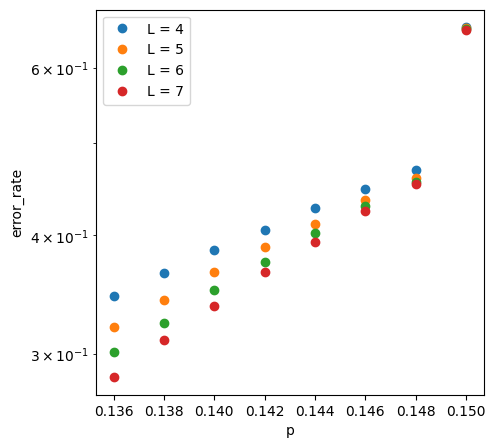

In [14]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.136, 0.138, 0.14, 0.142, 0.144, 0.146, 0.148, 0.15]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [15]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.136, 0.138, 0.14, 0.142, 0.144, 0.146, 0.148, 0.15]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 10000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [16]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [1.49538787e-01 1.65028763e+00 5.87130283e-01 1.46106244e+01
 1.97652604e+02]
Parameter standard deviations: [3.46192708e-04 1.51704298e-01 1.42152243e-02 1.66295079e+00
 3.81013668e+01]


np.float64(186.18727718321418)

In [17]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [1.50384942e-01 3.30154763e+00 6.75755940e-01 5.56475982e+01
 3.49846609e+03 7.57826119e+04]
Parameter standard deviations: [4.08413221e-04 3.24605440e-01 3.80299779e-02 6.89411724e+00
 4.92468062e+02 1.28335133e+04]


np.float64(118.64955201976908)

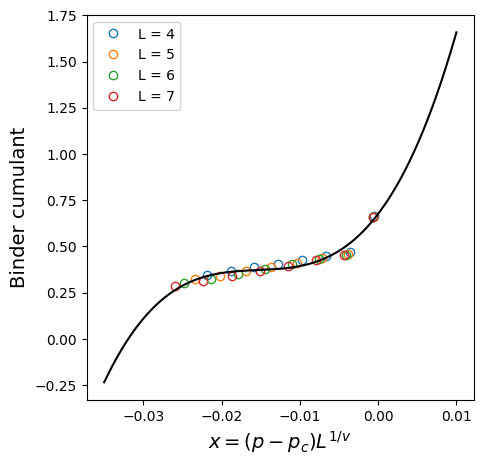

In [20]:
pc = 1.50384942e-01 
nu = 3.30154763e+00 
A = 6.75755940e-01
B = 5.56475982e+01
C = 3.49846609e+03 
D = 7.57826119e+04

p = [0.136, 0.138, 0.14, 0.142, 0.144, 0.146, 0.148, 0.15]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.035, 0.01, 1000)
y_data = A + B*x_data + C*(x_data**2) +D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()